# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [2]:
%load_ext autoreload
%autoreload 2
import sys
print(sys.executable)

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns



/Users/billyan/Documents/2026/CSCI1851/homework-3-ZYan31/hw3/bin/python


## Data Loading

In [3]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('/Users/billyan/Documents/2026/CSCI1851/homework-3-ZYan31/data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="/Users/billyan/Documents/2026/CSCI1851/homework-3-ZYan31/data/GSE139307.pkl")
desc_clf = X_clf.describe()
desc_aging = df_aging.describe()

Successfully loaded heart disease data with 1025 rows


/Users/billyan/Documents/2026/CSCI1851/homework-3-ZYan31/src/hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


In [4]:
# TODO: Inspect dataset shapes and missing values
# TODO: Print basic summary statistics for each dataset
print("X_clf shape: ", X_clf.shape, "\n")
print("y_clf shape:", y_clf.shape, "\n")

feature_names = list(X_clf.columns)
print("X_clf features \n", feature_names, "\n")

#print("Missing values for df_aging keys: ", df_aging.isnull().sum())
print("Missing values for X_clf: \n", X_clf.isnull().sum(), "\n")

# Print basic summary statistics for each dataset
print("X_clf summary statistics: \n", X_clf.describe(), "\n")
print("y_clf class statistics: \n", y_clf.value_counts(), "\n")

### For df_aging
feature_names_aging = list(df_aging.columns)
print("df_aging shape: ", df_aging.shape, "\n")
print("first 10 df_aging keys: \n", feature_names_aging[:10], "\n")
print("Df_aging summary statistics: \n", desc_aging, "\n")

X_clf shape:  (1025, 13) 

y_clf shape: (1025,) 

X_clf features 
 ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'] 

Missing values for X_clf: 
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64 

X_clf summary statistics: 
                age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000

## Classification Task (Heart Disease)

Exploring classification dataset...


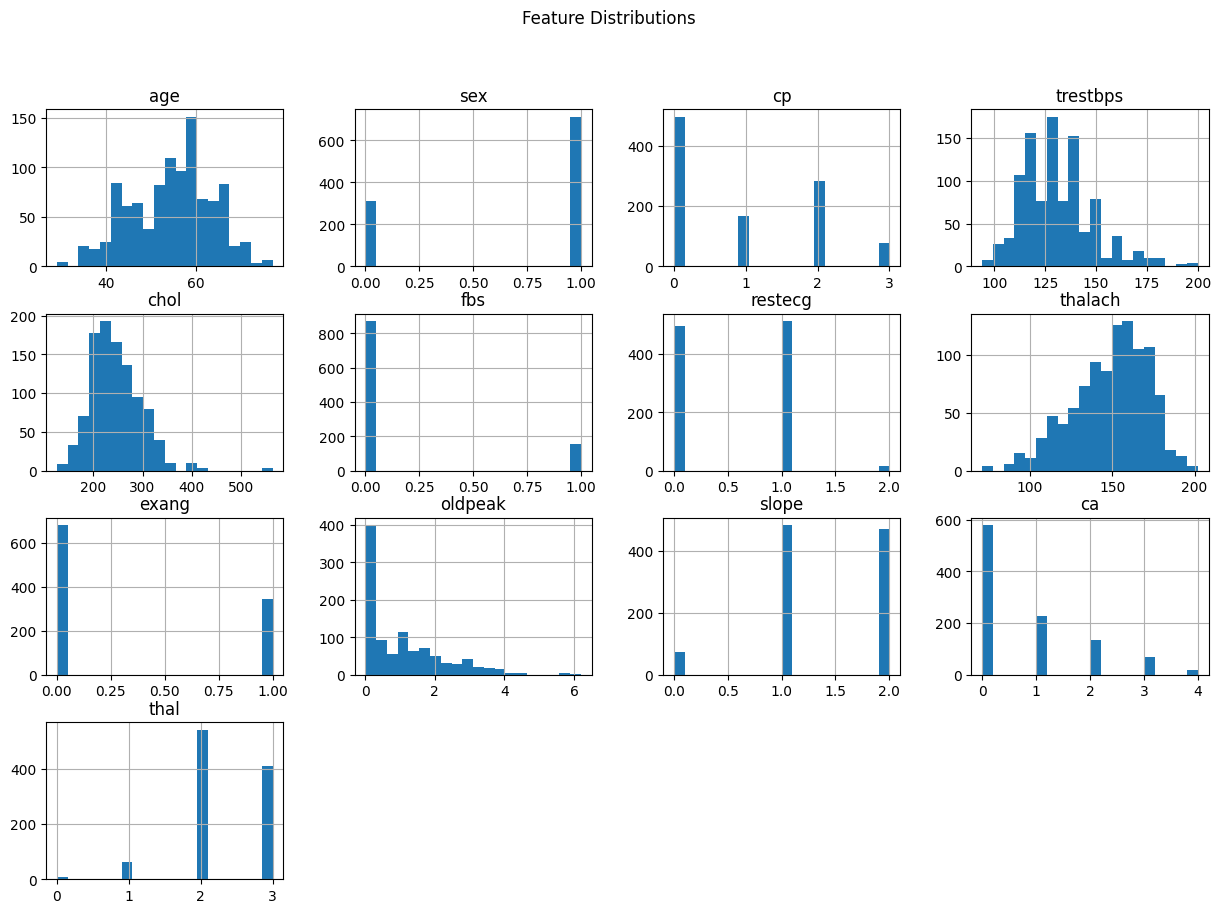

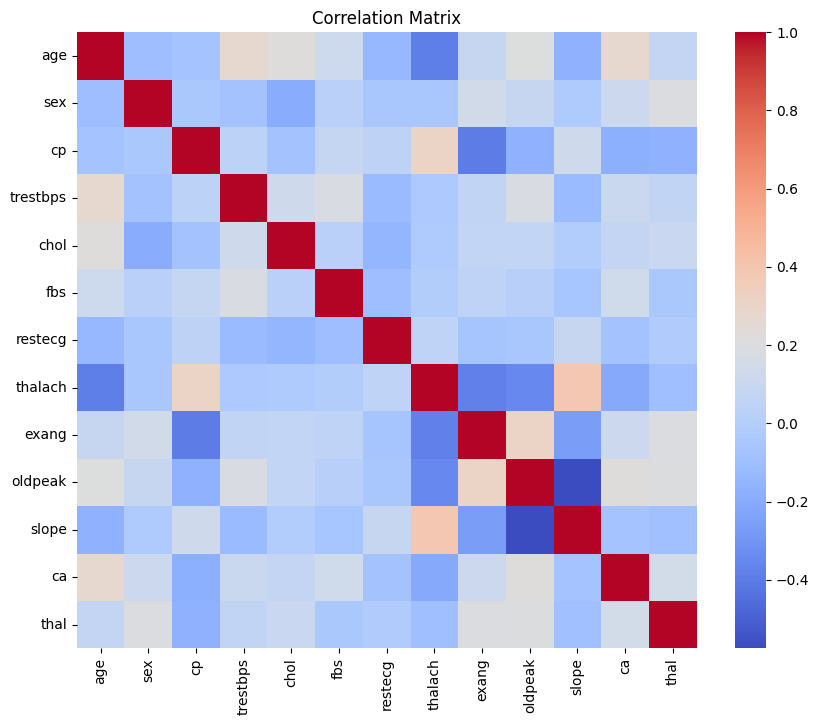

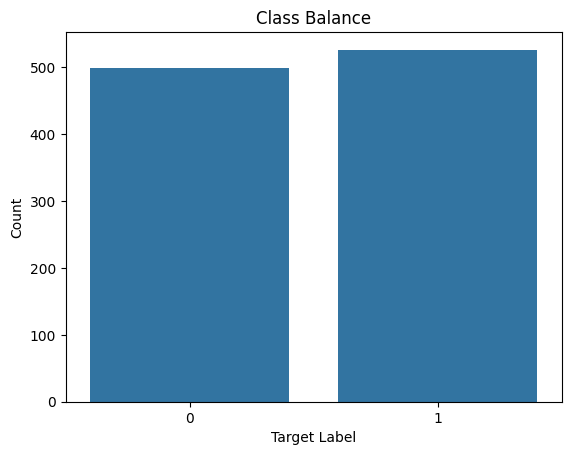

In [4]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils

explore_classification_data(X_clf, y_clf)

In [5]:
# TODO: Split X_clf and y_clf into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size = 0.2, random_state = 42)

### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [6]:
# TODO: Build a leakage-free pipeline for classification
# Example skeleton:
# pipeline = Pipeline([
#     ("imputer", ...),
#     ("scaler", ...),
#     # ("pca", ...),
#     ("model", svm_classifier(kernel=..., C=..., degree=..., gamma=...)),
# ])
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('model', svm_classifier(kernel='rbf', C=1.0, degree=3, gamma='scale'))
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

### Kernel Experiments

In [7]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
# 03/13/2026 can look at the different search strategies too - median, mean, etc.
C_search = [0.1, 1, 10, 100]
d_search = [1, 2, 3, 4, 5]
g_search = ['scale', 'auto', 0.01, 0.1, 1]
kernel_results = []
search_grid = {}
param_grid = {"linear": {"model__kernel": ["linear"], "model__C" : C_search, "model__degree" : d_search} , 
              "poly": {"model__kernel": ["poly"], "model__C" : C_search, "model__degree" : d_search, "model__gamma": g_search}, 
              "rbf": {"model__kernel": ["rbf"], "model__C" : C_search, "model__degree" : d_search, "model__gamma": g_search}}
for kernel, param in param_grid.items():
    search = GridSearchCV(estimator = pipeline, param_grid = param,  scoring = 'roc_auc', cv = 5, refit = True)
    search.fit(X_train, y_train)
    best_est = search.best_estimator_
    y_pred = best_est.predict(X_test)
    kernel_results.append({'kernel': kernel, 'best_params': search.best_params_, 'best_score': search.best_score_, 
                           'best_estimator': best_est, 'test_acc': accuracy_score(y_pred, y_test), 
                           'test_f1': f1_score(y_pred, y_test), 'roc_auc': roc_auc_score(y_pred, y_test)})
    search_grid[kernel] = search
results_df = pd.DataFrame(kernel_results).sort_values('roc_auc', ascending= False)
results_df
print(results_df)

   kernel                                        best_params  best_score  \
2     rbf  {'model__C': 10, 'model__degree': 1, 'model__g...    0.999256   
1    poly  {'model__C': 10, 'model__degree': 5, 'model__g...    0.990502   
0  linear  {'model__C': 0.1, 'model__degree': 1, 'model__...    0.919009   

                                      best_estimator  test_acc   test_f1  \
2  (SimpleImputer(strategy='median'), StandardSca...  0.985366  0.985222   
1  (SimpleImputer(strategy='median'), StandardSca...  0.946341  0.947867   
0  (SimpleImputer(strategy='median'), StandardSca...  0.819512  0.838428   

    roc_auc  
2  0.985714  
1  0.947499  
0  0.836649  


### Classification Metrics and Visuals

Best model parameters: {'model__C': 10, 'model__degree': 1, 'model__gamma': 1, 'model__kernel': 'rbf'}
Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.970873786407767
F1: 0.9852216748768473
ROC_AUC: 0.9857142857142857


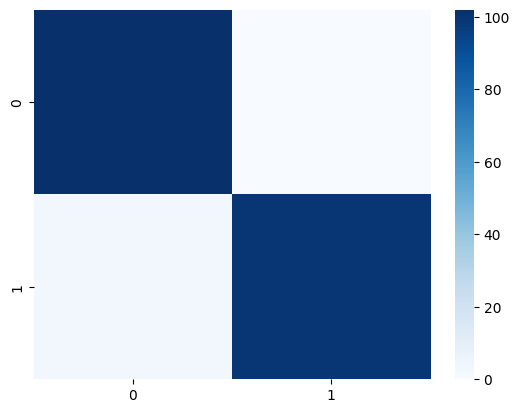

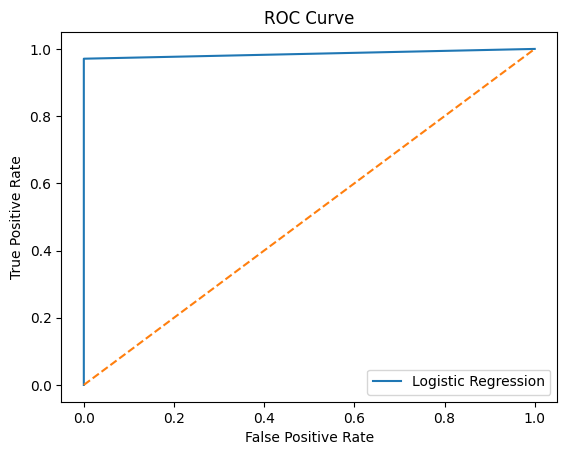

In [8]:
# TODO: Compute accuracy and F1
# TODO: Compute ROC-AUC or PR-AUC
# TODO: Plot confusion matrix and ROC/PR curve

best_kernel = results_df.iloc[0]["kernel"]
best_search = search_grid[best_kernel]
best_est = results_df.iloc[0]["best_estimator"]
accuracy, precision, recall, f1 = evaluate_classifier(best_est, X_test, y_test)
best_par = results_df.iloc[0]['best_params']
print("Best model parameters:", best_par)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC_AUC:", results_df.iloc[0]["roc_auc"])
cfm = confusion_matrix(y_test, best_est.predict(X_test))
sns.heatmap(cfm, cmap = "Blues")
# comparing the metrics, AUROC, AUPRC:
fpr, tpr, _ = roc_curve(y_test, best_est.predict(X_test))

# false positive rate, true positive rate, also negatives

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### Hyperparameter Sensitivity

/Users/billyan/Documents/2026/CSCI1851/homework-3-ZYan31/hw3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Controlled Sensitivity: Gamma vs results')

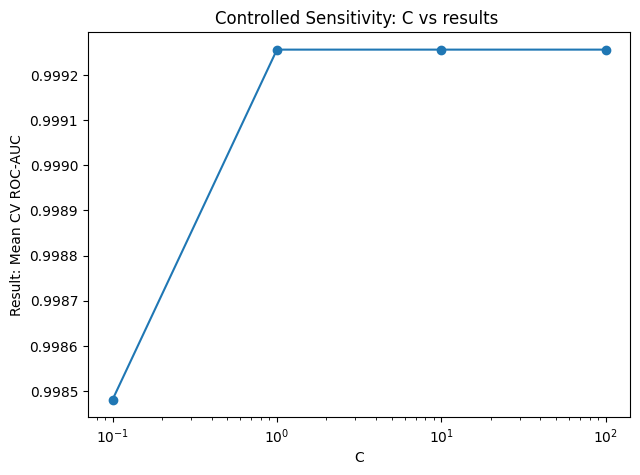

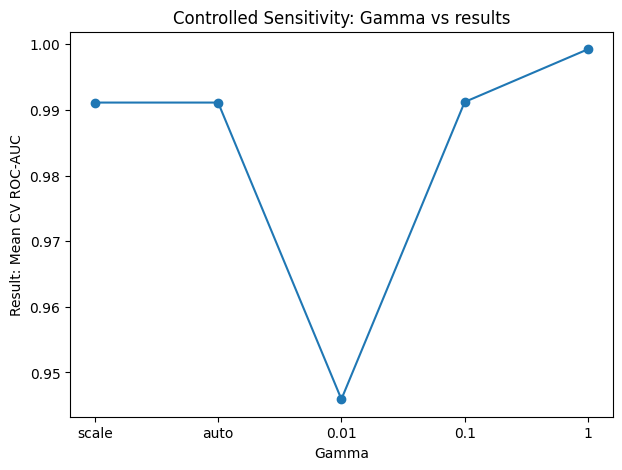

In [9]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree
# Example: line plot of F1 vs C for a fixed kernel
# best model params were kernel = poly, C = 100, degree = 5, gamma = scale. 
plot_classification_results(X_train, y_train, best_est, "cdf.png", "Best SVM Decision Boundary")
best_params = results_df.iloc[0]["best_params"]
filter_by_kernel = pd.DataFrame(search_grid[results_df.iloc[0]["kernel"]].cv_results_)
filter_C = filter_by_kernel[(filter_by_kernel["param_model__degree"] == best_params['model__degree']) & (filter_by_kernel["param_model__gamma"] == best_params['model__gamma'])]
filter_gamma = filter_by_kernel[(filter_by_kernel["param_model__C"] == best_params['model__C']) & (filter_by_kernel["param_model__degree"] == best_params['model__degree'])]
#print(filter_C)
plt.figure(figsize=(7, 5))
plt.plot(filter_C["param_model__C"].astype(float), filter_C["mean_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Result: Mean CV ROC-AUC")
plt.title( "Controlled Sensitivity: C vs results ")

plt.figure(figsize=(7, 5))
plt.plot(filter_gamma["param_model__gamma"].astype(str), filter_gamma["mean_test_score"], marker="o")
plt.xlabel("Gamma")
plt.ylabel("Result: Mean CV ROC-AUC")
plt.title( "Controlled Sensitivity: Gamma vs results")

## Regression Task (Biological Aging)

In [5]:
# TODO: Separate target column "target" from features

#for finding non-numerics
#print(df_aging.dtypes[df_aging.dtypes == "object"])
X_reg = df_aging.drop(columns=["age", "dataset", "tissue_type", "gender"])
X_reg = X_reg.drop(columns = X_reg.columns[X_reg.isna().all()])
y_reg = df_aging["age"]
metadata = {"dataset": df_aging["dataset"], "tissue_type":df_aging["tissue_type"], "gender":df_aging["gender"]}
# print("Duplicate column names:", df_aging.columns.duplicated().sum())
# # transpose, drop duplicate rows, transpose back
# df_aging_deduo = df_aging.T.drop_duplicates().T
# print("Original shape:", df_aging.shape)
# print("After removing duplicate-value columns:", df_aging_deduo.shape)

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
imputer = SimpleImputer(strategy="mean")
X_reg = pd.DataFrame(imputer.fit_transform(X_reg), columns=X_reg.columns)

# # Variance thresholding - does not work, model performance terrible
# vt = VarianceThreshold(threshold=0.02)
# X_reg_vt = vt.fit_transform(X_reg)
# kept = X_reg.columns[vt.get_support()]
# X_reg_vt = pd.DataFrame(X_reg_vt, columns=kept)
# print("Shape after variance thresholding:", X_reg_vt.shape)

# TODO: Split X_reg and y_reg into training and testing sets
# variance threshold on features
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size= 0.2, random_state=42)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [6]:
# TODO: Build a leakage-free pipeline for regression
# removed these things from pipeline because computing them each time is too expensive.
# caused kernel to crash many times
# ensured leakage free by doing scaling and pca on the training set, then applying to testing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector = SelectKBest(score_func=f_regression, k = 50)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

pca = PCA(n_components = 10)
X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca = pca.transform(X_test_sel)
pipeline2 = Pipeline([
    ("model", svm_regressor(kernel='rbf', C=1.0, degree=3, gamma='scale')),
])


### Kernel Experiments

In [7]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model
C_search = [0.01, 0.1, 1, 10, 100]
d_search = [2, 3, 4, 5]
g_search = ['scale', 0.01, 1, 10]
kernel_results = []
search_grid = {}
param_grid = {"linear": {"model__kernel": ["linear"], "model__C" : C_search, "model__degree" : d_search} , 
              "poly": {"model__kernel": ["poly"], "model__C" : C_search, "model__degree" : d_search, "model__gamma": g_search}, 
              "rbf": {"model__kernel": ["rbf"], "model__C" : C_search, "model__degree" : d_search, "model__gamma": g_search}}
for kernel, param in param_grid.items():
    print(f"Running {kernel}...")
    search = GridSearchCV(estimator = pipeline2, param_grid = param, scoring = 'r2', cv = 3, refit = True)
    search.fit(X_train_pca, y_train)
    best_est = search.best_estimator_
    y_pred = best_est.predict(X_test_pca)
    kernel_results.append({'kernel': kernel, 'best_params': search.best_params_, 'best_score': search.best_score_, 
                           'best_estimator': best_est, 'test_mae': mean_absolute_error(y_test, y_pred),
                           'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred)), 'test_r2': r2_score(y_test, y_pred)})
    search_grid[kernel] = search
results_df = pd.DataFrame(kernel_results).sort_values('test_r2', ascending= False)
results_df
print(results_df)

Running linear...
Running poly...
Running rbf...
   kernel                                        best_params  best_score  \
2     rbf  {'model__C': 10, 'model__degree': 2, 'model__g...    0.795092   
1    poly  {'model__C': 10, 'model__degree': 3, 'model__g...    0.533530   
0  linear  {'model__C': 0.1, 'model__degree': 2, 'model__...    0.850613   

                            best_estimator  test_mae  test_rmse   test_r2  
2        (SVR(C=10, degree=2, gamma=0.01))  4.155705   4.411717  0.400843  
1               (SVR(C=10, kernel='poly'))  4.361169   5.164040  0.179073  
0  (SVR(C=0.1, degree=2, kernel='linear'))  5.157002   5.572659  0.044017  


### Regression Metrics and Visuals

In [8]:
# TODO: Compute MAE, RMSE, and R^2
# TODO: Plot parity (predicted vs actual) and residuals
# plot_regression_results(...)
# plot_residuals(...)

best_kernel = results_df.iloc[0]["kernel"]
best_search = search_grid[best_kernel]
best_est = results_df.iloc[0]["best_estimator"]
mae, rmse, r2 = evaluate_regressor(best_est, X_test_pca, y_test)
y_pred = best_est.predict(X_test_pca)
best_par = results_df.iloc[0]['best_params']
print("Best model parameters:", best_par)
print("Mean Absolute Error:", mae)
print("Root Mean Square Error:", rmse)
print("R2:", r2)

plot_regression_results(
    y_test.to_numpy(),
    y_pred,
    filename="regression_parity.png",
    title=f"Predicted vs Actual ({best_kernel})"
)

plot_residuals(
    y_test.to_numpy(),
    y_pred,
    filename="regression_residuals.png",
    title=f"Residuals ({best_kernel})"
)

Best model parameters: {'model__C': 10, 'model__degree': 2, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Mean Absolute Error: 4.155704680759625
Root Mean Square Error: 4.411717232312735
R2: 0.40084274553888943


### Hyperparameter Sensitivity (Regression)

Text(0.5, 1.0, 'Controlled Sensitivity: Gamma vs results')

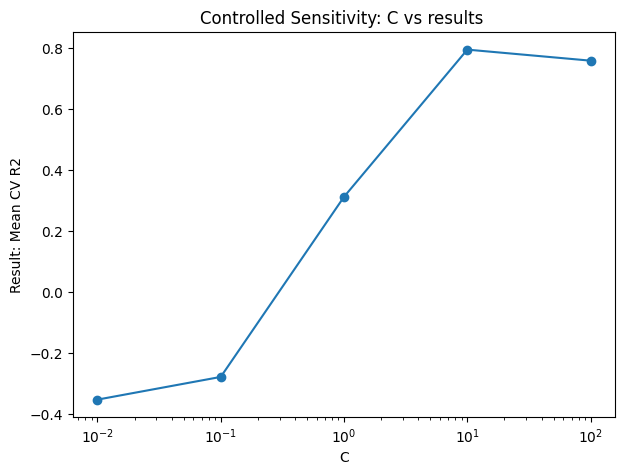

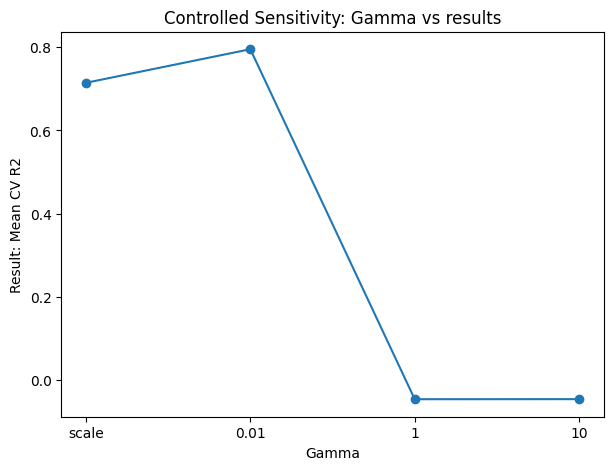

In [12]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel
# best model params were kernel = poly, C = 100, degree = 5, gamma = scale. 
plot_regression_results(y_test, y_pred, "cdf2.png")
best_params = results_df.iloc[0]["best_params"]
filter_by_kernel = pd.DataFrame(search_grid[results_df.iloc[0]["kernel"]].cv_results_)
filter_C = filter_by_kernel[(filter_by_kernel["param_model__degree"] == best_params['model__degree']) & (filter_by_kernel["param_model__gamma"] == best_params['model__gamma'])]
filter_gamma = filter_by_kernel[(filter_by_kernel["param_model__C"] == best_params['model__C']) & (filter_by_kernel["param_model__degree"] == best_params['model__degree'])]
#print(filter_C)
plt.figure(figsize=(7, 5))
plt.plot(filter_C["param_model__C"].astype(float), filter_C["mean_test_score"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Result: Mean CV R2")
plt.title( "Controlled Sensitivity: C vs results ")

plt.figure(figsize=(7, 5))
plt.plot(filter_gamma["param_model__gamma"].astype(str), filter_gamma["mean_test_score"], marker="o")
plt.xlabel("Gamma")
plt.ylabel("Result: Mean CV R2")
plt.title( "Controlled Sensitivity: Gamma vs results")